In [1]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Text Processing
import re
import string

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.sparse import hstack
from scipy.sparse import csr_matrix

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [8]:
data = pd.read_csv('C:\\Users\\vukre\\OneDrive\\Dokumen\\Desktop\\AI-Powered Career Intelligence Platform\\notebooks\\training_data.csv')
data

,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
0,R000000,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,2,Market Research|Maven|Java|REST API|Spring Boo...,Java Backend Developer,Technology
1,R000001,Education: Master's in Microbiology Experience...,Master's in Microbiology,3,Agile|Data Analysis|Precision|Problem Solving|...,Microbiologist,Science & Research
2,R000002,Education: Apprenticeship Experience: 2 years ...,Apprenticeship,2,React|Customer Service|Technical Knowledge|Plu...,Plumber,Skilled Trades
3,R000003,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,0,MySQL|Query Optimization|Symfony|Terraform|PHP...,PHP Developer,Technology
4,R000004,Education: Bachelor's in Design Experience: 3 ...,Bachelor's in Design,3,Problem Solving|Docker|Creativity|Scrum|Ansibl...,Art Director,Creative & Design
...,...,...,...,...,...,...,...
9995,R009995,Education: Certification Experience: 0 years S...,Certification,0,Technical Skills|Problem Solving|Technical Wri...,Sound Engineer,Entertainment & Media
9996,R009996,Education: Juris Doctor Experience: 2 years Sk...,Juris Doctor,2,Attention to Detail|Legal Research|Analysis|Co...,Law Clerk,Legal Services
9997,R009997,Education: Master's in IT Experience: 7 years ...,Master's in IT,7,ETL|Data Warehouse Design|Strategic Planning|P...,Data Warehouse Architect,Data & Analytics
9998,R009998,Education: Associate in Fitness Management Exp...,Associate in Fitness Management,5,AWS|Leadership|Fitness Industry Knowledge|Mana...,Fitness Manager,Sports & Recreation


In [9]:
data.head(3)

,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
0,R000000,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,2,Market Research|Maven|Java|REST API|Spring Boo...,Java Backend Developer,Technology
1,R000001,Education: Master's in Microbiology Experience...,Master's in Microbiology,3,Agile|Data Analysis|Precision|Problem Solving|...,Microbiologist,Science & Research
2,R000002,Education: Apprenticeship Experience: 2 years ...,Apprenticeship,2,React|Customer Service|Technical Knowledge|Plu...,Plumber,Skilled Trades


In [10]:
data.tail(3)

,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
9997,R009997,Education: Master's in IT Experience: 7 years ...,Master's in IT,7,ETL|Data Warehouse Design|Strategic Planning|P...,Data Warehouse Architect,Data & Analytics
9998,R009998,Education: Associate in Fitness Management Exp...,Associate in Fitness Management,5,AWS|Leadership|Fitness Industry Knowledge|Mana...,Fitness Manager,Sports & Recreation
9999,R009999,Education: Master's in Counseling Experience: ...,Master's in Counseling,0,Security Protocols|Active Listening|Counseling...,Counselor,Human Services & Social Work


In [11]:
data.shape

(10000, 7)

In [12]:
print(data.columns)

Index(['Resume ID', 'Resume Text', 'Education', 'Experience Years', 'Skills',
       'Job Role', 'Category'],
      dtype='str')


In [13]:
# Remove unnecessary columns
data = data.drop(columns=["Resume ID", "Category"])

In [14]:
print(data.columns)

Index(['Resume Text', 'Education', 'Experience Years', 'Skills', 'Job Role'], dtype='str')


In [15]:
data.isna().sum()

Resume Text         0
Education           0
Experience Years    0
Skills              0
Job Role            0
dtype: int64

In [16]:
print(data["Resume Text"].value_counts())

Resume Text
Education: Bachelor's in Computer Science Experience: 2 years Skills: Market Research, Maven, Java, REST API, Spring Boot, Microservices, Statistics, SQL                             1
Education: Master's in Microbiology Experience: 3 years Skills: Agile, Data Analysis, Precision, Problem Solving, Scala, Research, Business Development, Microbiology                 1
Education: Apprenticeship Experience: 2 years Skills: React, Customer Service, Technical Knowledge, Plumbing Systems, Problem Solving, PostgreSQL, Code Knowledge, Creativity         1
Education: Bachelor's in Computer Science Experience: 0 years Skills: MySQL, Query Optimization, Symfony, Terraform, PHP, HTML/CSS, API Development, Financial Analysis               1
Education: Bachelor's in Design Experience: 3 years Skills: Problem Solving, Docker, Creativity, Scrum, Ansible, Communication, Team Leadership, Design Principles                    1
                                                                    

In [17]:
print(data["Education"].value_counts())

Education
Bachelor's in Computer Science      1425
High School                          722
Bachelor's in IT                     453
Bachelor's in Business               426
MBA                                  181
                                    ... 
Law School Graduate                    7
Customer Success Certification         7
Diesel Certification                   7
Master's in Occupational Therapy       6
Bachelor's in Supply Chain             6
Name: count, Length: 257, dtype: int64


In [18]:
print(data["Experience Years"].value_counts())

Experience Years
3     1842
2     1830
4     1758
1     1570
5     1165
0      820
6      463
7      157
8      133
9       77
10      69
13      48
11      39
12      29
Name: count, dtype: int64


In [19]:
print(data["Skills"].value_counts())

Skills
Market Research|Maven|Java|REST API|Spring Boot|Microservices|Statistics|SQL                                                               1
Agile|Data Analysis|Precision|Problem Solving|Scala|Research|Business Development|Microbiology|Laboratory Work                             1
React|Customer Service|Technical Knowledge|Plumbing Systems|Problem Solving|PostgreSQL|Code Knowledge|Creativity|Safety|iOS                1
MySQL|Query Optimization|Symfony|Terraform|PHP|HTML/CSS|API Development|Financial Analysis|Web Accessibility|Laravel|C++                   1
Problem Solving|Docker|Creativity|Scrum|Ansible|Communication|Team Leadership|Design Principles|Artistic Direction|Visual Communication    1
                                                                                                                                          ..
Technical Skills|Problem Solving|Technical Writing|Precision|Audio Engineering|Sound Design|Equipment Knowledge|React|Data Analysis        1
Attent

In [20]:
print(data["Job Role"].value_counts())

Job Role
Java Backend Developer    50
Automotive Engineer       47
Electronics Engineer      44
School Principal          44
Announcer                 43
                          ..
Personal Trainer          20
Controller                20
Oracle DBA                19
Lawyer                    18
Carpenter                 18
Name: count, Length: 324, dtype: int64


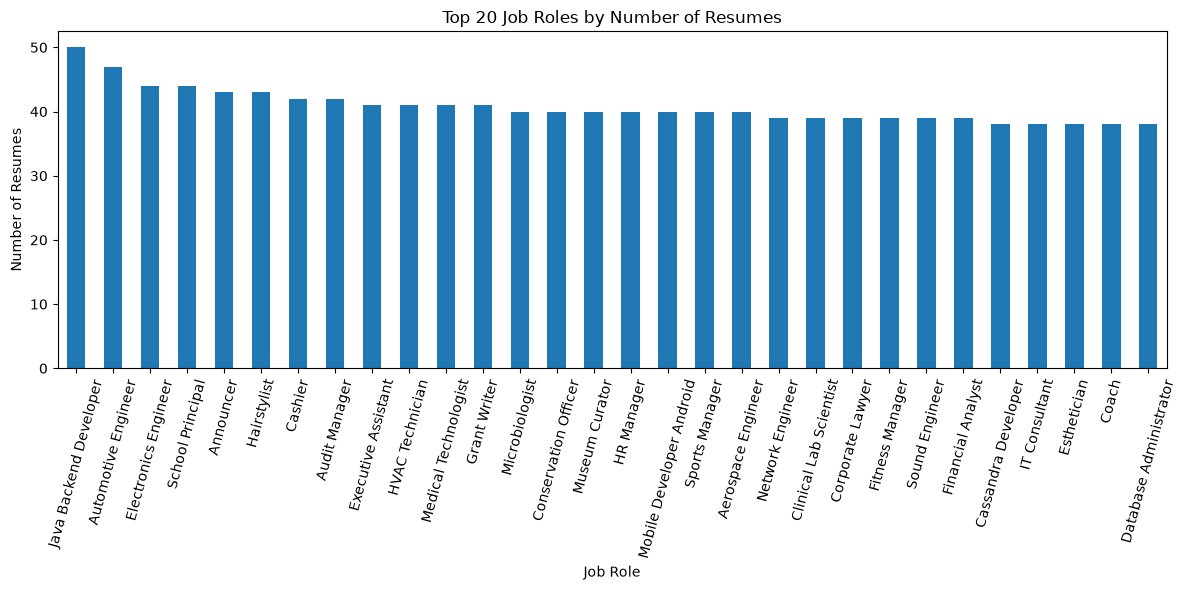

In [21]:
import matplotlib.pyplot as plt

top_roles = data["Job Role"].value_counts().head(30)

plt.figure(figsize=(12, 6))
top_roles.plot(kind="bar")
plt.title("Top 20 Job Roles by Number of Resumes")
plt.xlabel("Job Role")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

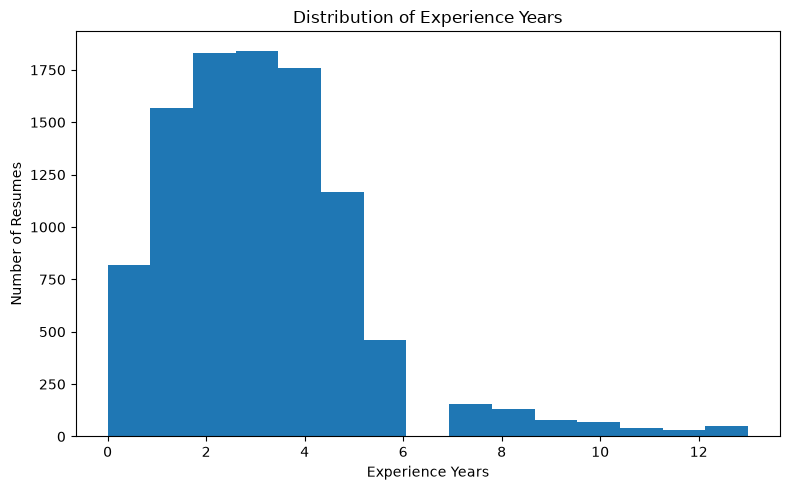

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(data["Experience Years"], bins=15)
plt.title("Distribution of Experience Years")
plt.xlabel("Experience Years")
plt.ylabel("Number of Resumes")
plt.tight_layout()
plt.show()

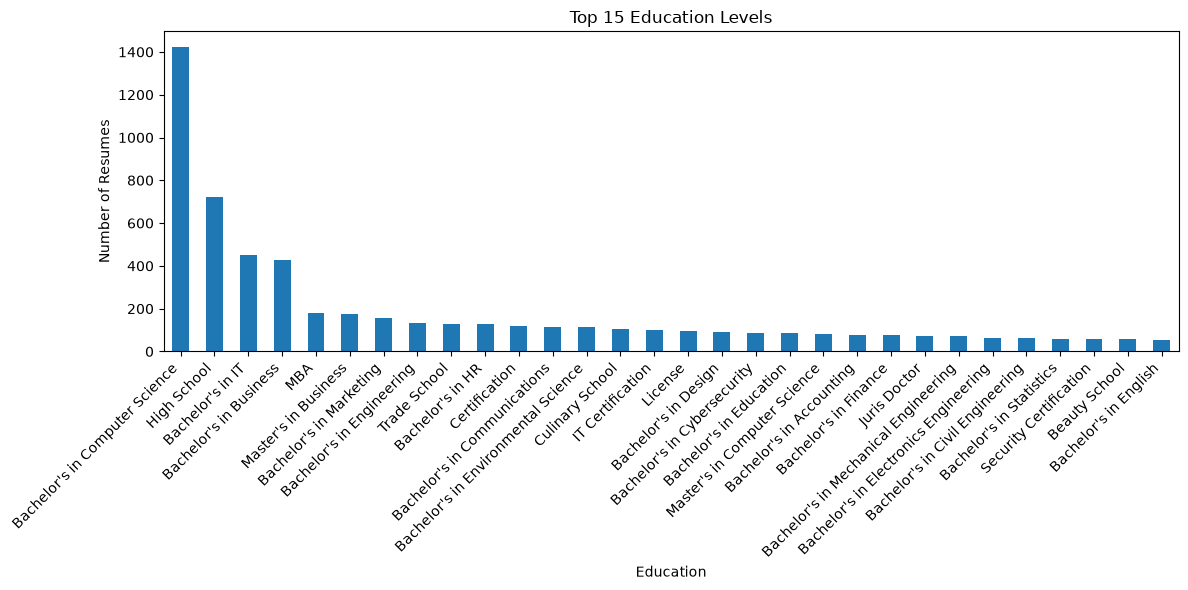

In [23]:
education_counts = data["Education"].value_counts().head(30)

plt.figure(figsize=(12, 6))
education_counts.plot(kind="bar")

plt.title("Top 15 Education Levels")
plt.xlabel("Education")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [24]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Clean input text columns
data["Resume Text"] = data["Resume Text"].apply(clean_text)
data["Skills"] = data["Skills"].apply(clean_text)

In [25]:
X = data[[
    "Resume Text",
    "Skills",
    "Education",
    "Experience Years"
]]

y = data["Job Role"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

resume_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)
X_train_resume = resume_tfidf.fit_transform(X_train["Resume Text"])
X_test_resume = resume_tfidf.transform(X_test["Resume Text"])
print("Training Resume Shape:", X_train_resume.shape)
print("Testing Resume Shape:", X_test_resume.shape)

Training Resume Shape: (8000, 5000)
Testing Resume Shape: (2000, 5000)


In [28]:
skills_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)
X_train_skills = skills_tfidf.fit_transform(X_train["Skills"])
X_test_skills = skills_tfidf.transform(X_test["Skills"])
print("Training Skills Shape:", X_train_skills.shape)
print("Testing Skills Shape:", X_test_skills.shape)

Training Skills Shape: (8000, 3000)
Testing Skills Shape: (2000, 3000)


In [29]:
from sklearn.preprocessing import OneHotEncoder

education_encoder = OneHotEncoder(handle_unknown="ignore")

X_train_education = education_encoder.fit_transform(
    X_train[["Education"]]
)
X_test_education = education_encoder.transform(
    X_test[["Education"]]
)
print("Education Training Shape:", X_train_education.shape)
print("Education Testing Shape:", X_test_education.shape)

Education Training Shape: (8000, 257)
Education Testing Shape: (2000, 257)


In [30]:
X_train_experience = X_train[["Experience Years"]].values
X_test_experience = X_test[["Experience Years"]].values

In [31]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_resume,
    X_train_skills,
    X_train_education,
    X_train_experience
])

X_test_final = hstack([
    X_test_resume,
    X_test_skills,
    X_test_education,
    X_test_experience
])
print("Final Training Shape:", X_train_final.shape)
print("Final Testing Shape:", X_test_final.shape)

Final Training Shape: (8000, 8258)
Final Testing Shape: (2000, 8258)


In [32]:
from sklearn.preprocessing import LabelEncoder

job_role_encoder = LabelEncoder()

y_train_encoded = job_role_encoder.fit_transform(y_train)
y_test_encoded = job_role_encoder.transform(y_test)
print("Number of Job Roles:", len(job_role_encoder.classes_))
print("Training Target Shape:", y_train_encoded.shape)
print("Testing Target Shape:", y_test_encoded.shape)

Number of Job Roles: 324
Training Target Shape: (8000,)
Testing Target Shape: (2000,)


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_final, y_train_encoded)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [34]:
y_pred = model.predict(X_test_final)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9995
Accuracy (%): 99.95


In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=job_role_encoder.classes_,
    zero_division=0
))

                                 precision    recall  f1-score   support

                      3D Artist       1.00      1.00      1.00         7
               AI/ML Specialist       1.00      1.00      1.00         5
                AR/VR Developer       1.00      1.00      1.00         7
               Academic Advisor       1.00      1.00      1.00         5
          Academic Data Analyst       1.00      1.00      1.00         6
              Account Executive       1.00      1.00      1.00         7
                     Accountant       1.00      1.00      1.00         7
       Administrative Assistant       1.00      1.00      1.00         6
             Aerospace Engineer       1.00      1.00      1.00         8
          Agricultural Engineer       1.00      1.00      1.00         7
             Analytics Engineer       1.00      1.00      1.00         6
              Angular Developer       1.00      1.00      1.00         6
                       Animator       1.00      1.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [38]:
rf_pred = rf_model.predict(X_test_final)

In [39]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test_encoded, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.999
Random Forest Accuracy (%): 99.9


In [40]:
import xgboost as xgb
print(xgb.__version__)

3.3.0


In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.5,
    objective="multi:softmax",
    num_class=324,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train_final, y_train_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

In [42]:
xgb_pred = xgb_model.predict(X_test_final)

In [43]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(
    y_test_encoded,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Accuracy (%):", xgb_accuracy * 100)

XGBoost Accuracy: 0.997
XGBoost Accuracy (%): 99.7


In [44]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
TfidfVectorizer          type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                        DataFrame                 Shape: (10000, 4)
XGBClassifier            type                      <class 'x

In [45]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

print("All three models saved successfully!")

All three models saved successfully!


In [41]:
import os

for file in [
    "logistic_regression_model.pkl",
    "random_forest_model.pkl",
    "xgboost_model.pkl"
]:
    print(file, "→", os.path.exists(file))

logistic_regression_model.pkl → True
random_forest_model.pkl → True
xgboost_model.pkl → True
